# Evaluate wopke_100 extraction runs

Scores predictions in `outputs/<model_tag>/by_paper/` against the wopke_100 ground-truth CSV.
Scoring (field similarity, value+unit, crop-1/2 swap, greedy row match) is reused from `src.experimentutils.eval_utils`.

1. **This cell + next:** pick one model tag → overall score + plots.
2. **Last cell:** pick one paper (and optionally one method) → FIELD / EXTRACTED / GT / SCORE.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

repo_root = Path.cwd().resolve()
for p in [repo_root, *repo_root.parents]:
    if (p / "src").is_dir() and (p / "outputs").is_dir():
        repo_root = p
        break

eval_dir = repo_root / "notebooks" / "eval"
for path in (repo_root, eval_dir):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import wopke_eval as we

runs = we.list_model_runs(repo_root / "outputs")
print("repo_root:", repo_root)
print("Available model runs:\n")
runs

repo_root: /home/com3dian/Github/meta_analysis_agents
Available model runs:



,tag,run_dir,n_papers,n_direct_llm,n_workflow,n_MAS
0,google_gemini-2-5-flash_42fields,/home/com3dian/Github/meta_analysis_agents/out...,2,2,2,2
1,surf_Qwen-Qwen3-6-27B-FP8_42fields,/home/com3dian/Github/meta_analysis_agents/out...,62,48,46,62
2,surf_Qwen-Qwen3-6-35B-A3B-FP8_42fields,/home/com3dian/Github/meta_analysis_agents/out...,87,86,76,86
3,surf_RedHatAI-gemma-4-31B-it-NVFP4_42fields,/home/com3dian/Github/meta_analysis_agents/out...,81,70,65,80
4,surf_Sehyo-Qwen3-5-122B-A10B-NVFP4_42fields,/home/com3dian/Github/meta_analysis_agents/out...,81,71,68,80
5,surf_default-text-large_42fields,/home/com3dian/Github/meta_analysis_agents/out...,78,75,76,77
6,surf_mistralai-Mistral-Small-3-2-24B-Instruct-...,/home/com3dian/Github/meta_analysis_agents/out...,29,13,0,28
7,surf_openai-gpt-oss-120b_42fields,/home/com3dian/Github/meta_analysis_agents/out...,81,76,75,81


## Score one model

Set `MODEL_TAG` to a folder name from the table above (or copy from `notebooks/experiment/run_wopke_100_*.ipynb`).
Re-run this cell for a different model.

tag           : surf_Sehyo-Qwen3-5-122B-A10B-NVFP4_42fields
methods       : ['direct_llm', 'workflow', 'MAS']
n papers      : 81
shared fields : 42
  direct_llm: 71 CSVs
  workflow: 68 CSVs
  MAS: 80 CSVs
paper_ids     : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20] ...



Scoring papers:   0%|          | 0/243 [00:00<?, ?it/s]

Overall mean scores — surf_Sehyo-Qwen3-5-122B-A10B-NVFP4_42fields
-----------------------------------------------------------------
  direct_llm    papers= 81  overall=0.345  TP-sim=0.531  factual=0.572  retrieval=0.685  f1=0.431
  workflow      papers= 81  overall=0.340  TP-sim=0.506  factual=0.559  retrieval=0.610  f1=0.389
  MAS           papers= 81  overall=0.225  TP-sim=0.313  factual=0.397  retrieval=0.466  f1=0.285



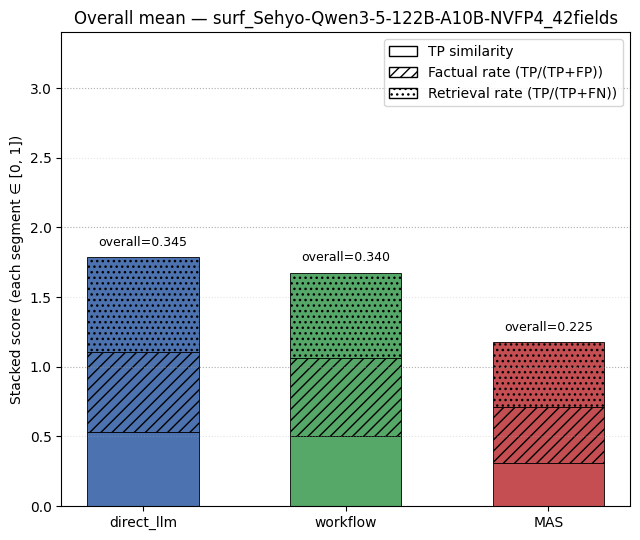

Per-paper plot: showing first 30 of 81 papers (set max_papers_in_plot to change).


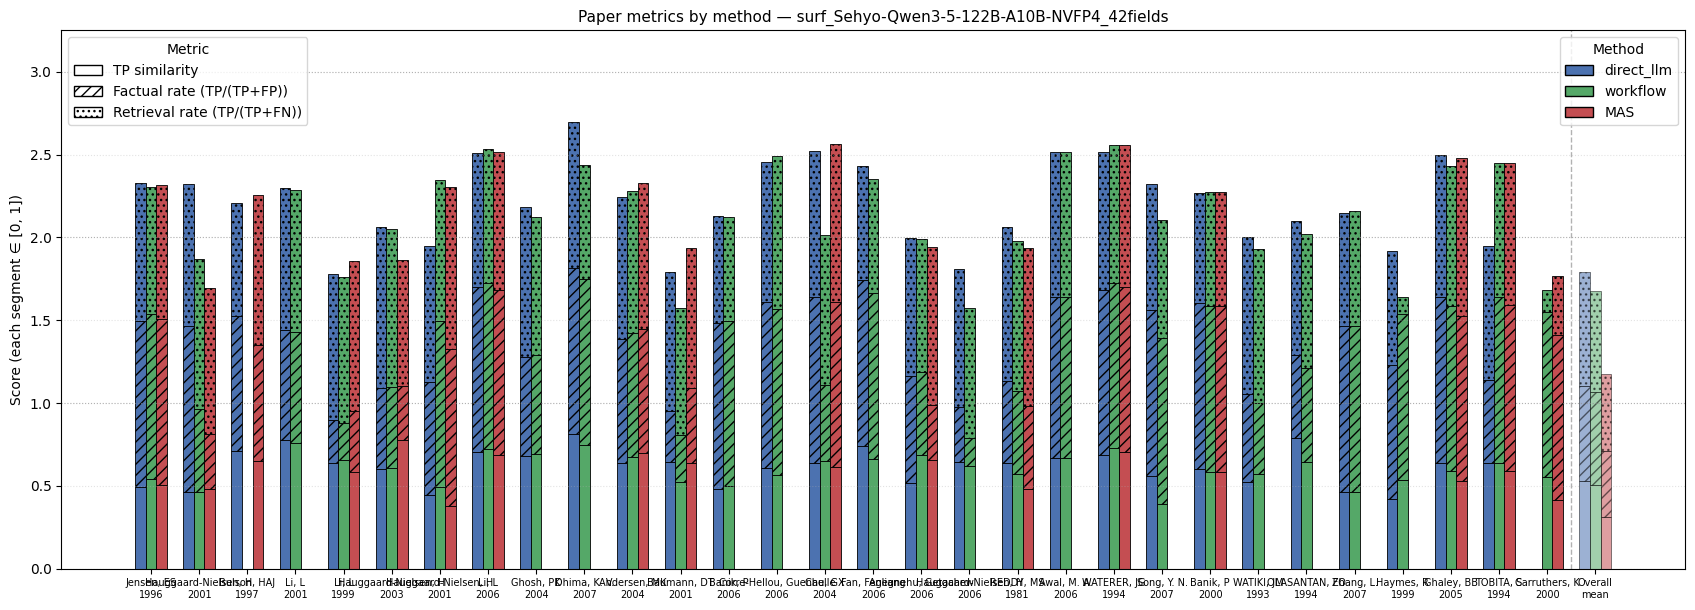

Matching records:   0%|          | 0/185 [00:00<?, ?it/s]

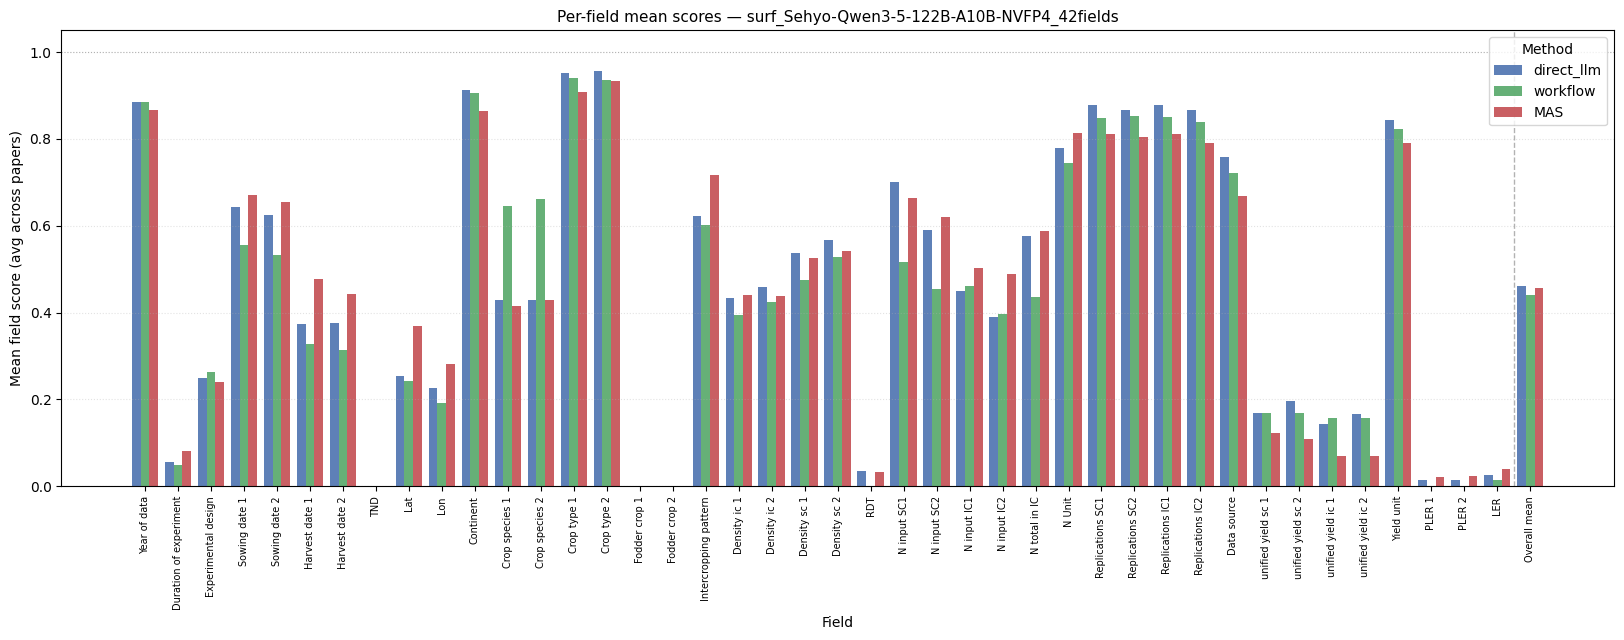

,method,n_papers,similarity,factual_rate,retrieval_rate,overall_score,f1,stacked_total
0,direct_llm,81,0.531163,0.571930,0.685409,0.345356,0.430895,1.788502
1,workflow,81,0.505969,0.558924,0.610282,0.340485,0.389392,1.675176
2,MAS,81,0.313003,0.397030,0.465839,0.225239,0.284534,1.175872


In [ ]:
# MODEL_TAG = "surf_mistralai-Mistral-Small-3-2-24B-Instruct-2506_42fields"
# MODEL_TAG = "surf_Qwen-Qwen3-6-35B-A3B-FP8_42fields"
# MODEL_TAG = "surf_openai-gpt-oss-120b_42fields"
# MODEL_TAG = "surf_RedHatAI-gemma-4-31B-it-NVFP4_42fields"
# MODEL_TAG = "surf_Sehyo-Qwen3-5-122B-A10B-NVFP4_42fields"
# MODEL_TAG = "surf_default-text-large_42fields"
MODEL_TAG = "surf_Qwen-Qwen3-6-27B-FP8_42fields"
# MODEL_TAG = "google_gemini-2-5-flash_42fields"

run = we.load_model_run(MODEL_TAG, outputs_root=repo_root / "outputs")
print("tag           :", run.tag)
print("methods       :", run.methods)
print("n papers      :", len(run.paper_ids))
print("shared fields :", len(run.shared_fields))
for m in run.methods:
    print(f"  {m}: {len(run.pred_by_method[m])} CSVs")
print("paper_ids     :", run.paper_ids[:20], "..." if len(run.paper_ids) > 20 else "")
print()

# Re-run setup cell after editing wopke_eval.py (or: import importlib; importlib.reload(we))
result = we.eval_model(run)  # ~30–60 s for 80+ papers; tqdm shows progress
result["mean"]

## One model, one paper vs ground truth

Uses the `run` loaded above. Set `PAPER_ID` (GT `Study#`) and optionally `METHOD`
(`"direct_llm"`, `"workflow"`, `"MAS"`, or `None` for every method that has a CSV).

Printed columns match `print_matching_pairs`: **FIELD / EXTRACTED / GT / SCORE**.

In [ ]:
PAPER_ID = run.paper_ids[0] if run.paper_ids else 1
METHOD = None  # e.g. "MAS" | "direct_llm" | "workflow" | None = all methods

# Optional: restrict the printed fields (None = all shared fields)
SHOW_FIELDS = None
# SHOW_FIELDS = [
#     "Crop species 1", "Crop species 2",
#     "unified yield sc 1", "unified yield sc 2",
#     "unified yield ic 1", "unified yield ic 2",
#     "Yield unit",
# ]

we.print_paper_vs_gt(
    run,
    PAPER_ID,
    METHOD,
    show_fields=SHOW_FIELDS,
)